In [267]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [268]:
data_path = Path.home() / "Documents" / "data-science-course"
df=pd.read_csv(data_path / "Advertising.csv")
print(df.head())

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [269]:
x=df['TV']
y=df['sales']

In [270]:
def knn_model(x_train, y_train, k, x_grid):
    y_pred=[]
    for x in x_grid:
        distance= np.abs(x_train - x)
        nearests= np.argsort(distance)[:k]
        y_pred.append(np.mean(y_train.iloc[nearests]))
    return np.array(y_pred)

In [271]:
order = np.argsort(x)
x=x[order]
y=y[order]
x_grid=np.linspace(min(x), max(x), len(x))

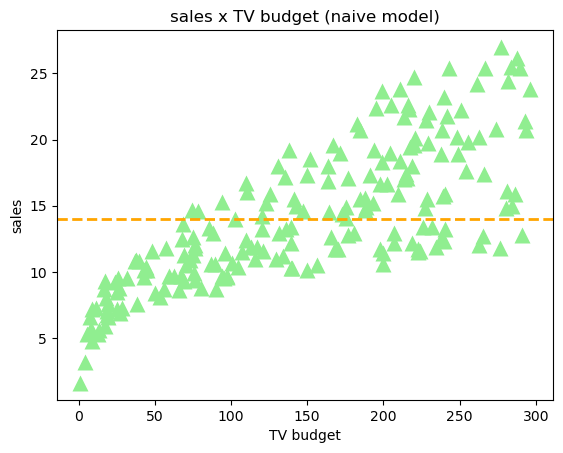

In [272]:
y_naive=y.mean()

plt.plot(x, y, marker= '^',linestyle= 'none', markersize= '12', markeredgecolor='none', markerfacecolor= 'lightgreen')
plt.axhline(y_naive, color='orange', linestyle='--', linewidth='2')
plt.title('sales x TV budget (naive model)')
plt.xlabel('TV budget')
plt.ylabel('sales')
plt.show()  

[]

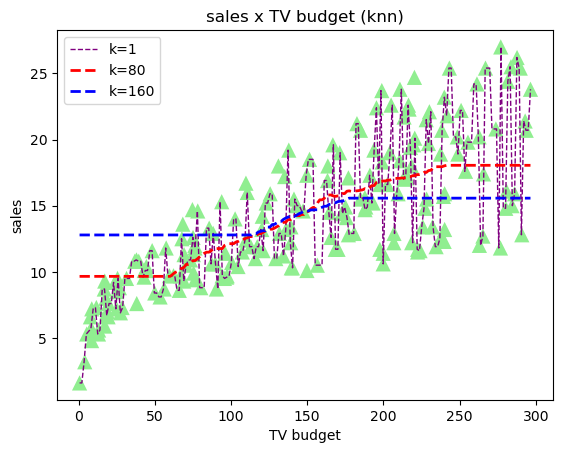

In [273]:
k_values=[1, 80, 160]
pred = {k: knn_model(x,y,k, x_grid) for k in k_values}
colors= ['purple','red', 'blue']
lines=[1,2,2]
plt.scatter(x, y, marker='^', color='lightgreen', edgecolor='none', s=120)
for color, line, (i, y_hat) in zip(colors,lines, pred.items()):
    plt.plot(x_grid, y_hat, color= color, linestyle='--', label= f'k={i}', linewidth=line)
plt.title('sales x TV budget (knn)')
plt.ylabel('sales')
plt.xlabel('TV budget')
plt.legend()
plt.plot()


In [274]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.20, random_state=42)
k_values=[_ for _ in range(1,10)]
y_pred={k: knn_model(x_train, y_train, k, x_test) for k in k_values}
mse_model={}
r2={}
y_mean_test=np.mean(y_test)
mse_media=(sum((y_test - y_mean_test) **2))/len(y_test)
for k, yz in y_pred.items():
    sumerror=0
    for i in range(len(y_test)):
        sumerror+=((y_test.iloc[i]-yz[i])**2)
    mse_model[k]=sumerror/len(y_test)
    r2[k]=1-(mse_model[k]/mse_media)

mse_model=dict(sorted(mse_model.items()))
r2=dict(sorted(r2.items()))
print(mse_media)
print(mse_model)
print(r2)
print(max(r2.values()))


18.50234375
{1: np.float64(17.303500000000007), 2: np.float64(16.21725), 3: np.float64(12.406055555555557), 4: np.float64(12.443296874999996), 5: np.float64(13.386219999999998), 6: np.float64(13.700638888888895), 7: np.float64(13.735418367346941), 8: np.float64(12.909027343750001), 9: np.float64(12.740231481481484)}
{1: np.float64(0.06479415614575823), 2: np.float64(0.12350293459443484), 3: np.float64(0.32948734910648514), 4: np.float64(0.32747455981083506), 5: np.float64(0.2765121986234854), 6: np.float64(0.2595187358958838), 7: np.float64(0.2576390022292748), 8: np.float64(0.3023031288265845), 9: np.float64(0.3114260737112571)}
0.32948734910648514


// MSE for every knn_model calculated //

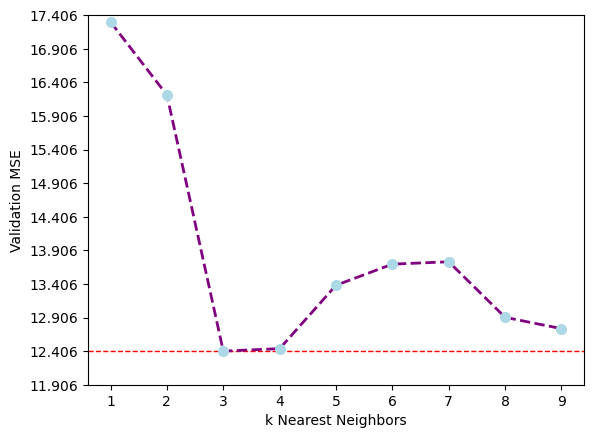

In [275]:
ymin=min(mse_model.values())
ymax=max(mse_model.values())
plt.axhline(ymin, linestyle='--', color='red', marker='none', linewidth=1)
plt.plot(list(mse_model.keys()), list(mse_model.values()), marker='o', linestyle='--', markerfacecolor='lightblue', markeredgecolor='none', color='purple', markersize='8', linewidth=2)
plt.xlabel('k Nearest Neighbors')
plt.ylabel('Validation MSE')
plt.ylim((ymin, ymax))
plt.yticks(np.arange(ymin-0.5, ymax+0.5, 0.5))
plt.show()

// plot all the Knn_models calculated // 

// Linear Regression //

In [276]:
def fit_and_plot(x, y, test_s=0.2, x_name='none', y_name='none'):

    x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=test_s, random_state=42)
    model = LinearRegression()

    model.fit(x_train,y_train)
    y_pred_train=model.predict(x_train)
    y_pred_test=model.predict(x_test)

    plt.scatter(x_train, y_train, marker='o', s=40, color='lightblue', label='Train data')
    plt.scatter(x_test,y_test, marker='o', color='red', s=40, label= 'Test data')
    plt.plot(x_train, y_pred_train, linestyle='-', color='purple', label='Train prediction', linewidth=1)
    plt.plot(x_test, y_pred_test, linestyle='--',label='Test prediction', color='teal', linewidth=1)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.legend()
    plt.show()

    r2_train= r2_score(y_train, y_pred_train)
    r2_test= r2_score(y_test,y_pred_test)


    return r2_train, r2_test, model



In [277]:
def fit_and_plot_multi(x, test_s=0.2):
    df_name_colums=list(x.columns[1:])
    x_p=np.array(x.iloc[:, 1:-1])
    y_p= np.array(x.iloc[:,-1])

    x_train, x_test, y_train, y_test= train_test_split(x_p, y_p, test_size=test_s, random_state=42)
    model= LinearRegression()
    model.fit(x_train, y_train)
    y_pred_train=model.predict(x_train)
    y_pred_test=model.predict(x_test)

    fig= plt.figure(figsize=(18,6))
    pairs= [(0,1), (0,2), (1,2)]
    for i, (a,b) in enumerate(pairs,1):
        ax= fig.add_subplot(1,3,i, projection= '3d')
        x1=np.linspace(x_train[:,a].min(), x_train[:,a].max(), 70)
        x2=np.linspace(x_train[:,b].min(), x_train[:,b].max(),70)
        X1,X2= np.meshgrid(x1,x2)

        others= np.mean(x_train, axis=0)
        X_pred= np.zeros((X1.size, x_train.shape[1]))
        X_pred[:,a]= X1.ravel()
        X_pred[:,b]= X2.ravel()
        for j in range(x_train.shape[1]):
            if j not in (a,b):
                X_pred[:,j]= others[j]
        y_pred=model.predict(X_pred).reshape(X1.shape)

        ax.plot_surface(X1,X2, y_pred, alpha=0.3, cmap= 'viridis', label='Prediction (gradient color)')
        ax.scatter(x_train[:,a], x_train[:,b], y_train, color='red', label='Train data', s=25)
        ax.scatter(x_test[:, a], x_test[:,b], y_test, color='blue', label= 'Test data', s=30)
        ax.set_xlabel(f'Predictor {df_name_colums[a]}')
        ax.set_ylabel(f'Predictor {df_name_colums[b]}')
        ax.set_zlabel('Sales')
        ax.view_init(15, 60)
        ax.legend()
    plt.tight_layout()
    plt.show()



    r2_train= r2_score(y_train, y_pred_train)
    r2_test= r2_score(y_test, y_pred_test)

    return r2_train, r2_test, model

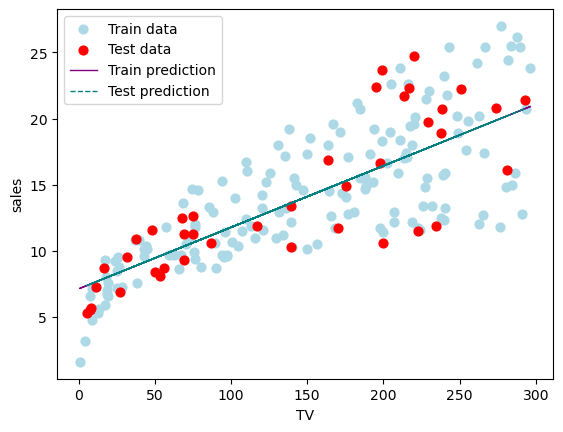

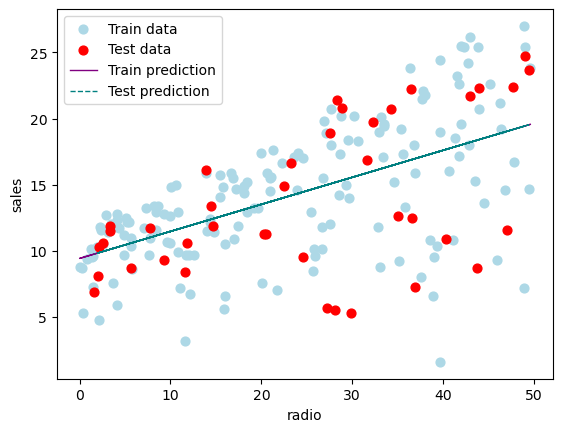

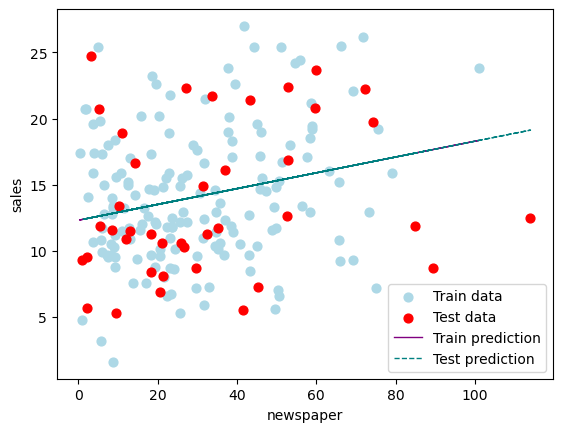

In [278]:
reg=LinearRegression()
y_name='sales'
df_names=[i for i in df.columns if i != y_name]
df_names=df_names[1:]
df_models=pd.DataFrame(columns=['Predictor', 'R2_Train', 'R2_Test', 'Intercept(β0)', 'Slope(β1)', 'Slope(β2)', 'Slope(β3)' ])
for name in df_names:
    r2_train, r2_test, model= fit_and_plot(df[[name]], df[y_name], x_name=name, y_name=y_name)
    df_models.loc[len(df_models)]=[name, r2_train, r2_test, model.intercept_, model.coef_, 0, 0]

#print(f'Slope (b0): {reg_linear.intercept_}')
#print(f'Intercept (b1): {reg_linear.coef_}')

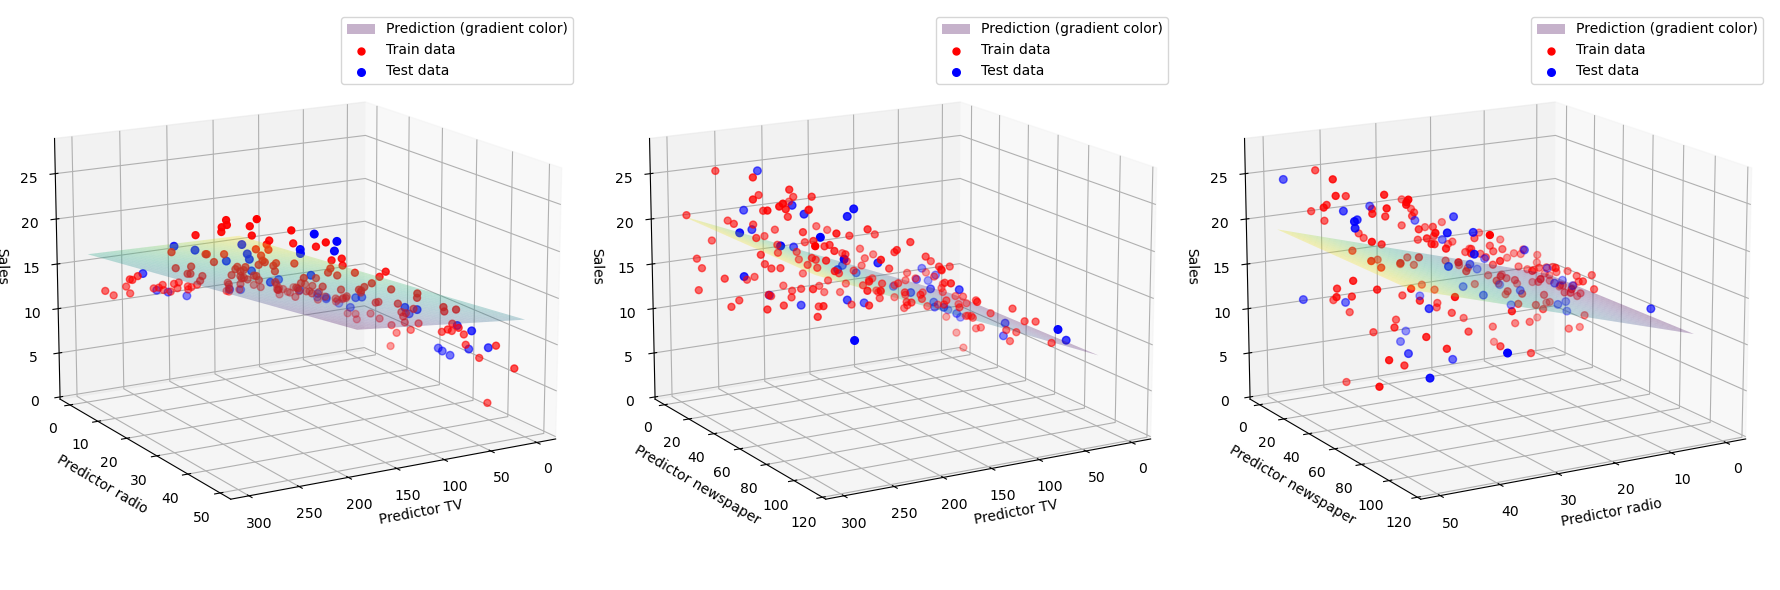

In [280]:
#linear regression with multi variables
x=df
r2_train, r2_test, model= fit_and_plot_multi(x)
list_slopes=model.coef_
df_models.loc[len(df_models)]=['Multi', r2_train, r2_test, model.intercept_, list_slopes[0], list_slopes[1], list_slopes[2]]

In [ ]:
df_models=df_models.sort_values(by='R2_Train', ascending=True)
df_models
#The R-Squared represents how much better the model is, if its close to 1 the model its good, if it close to 0, the model 

,Predictor,R2_Train,R2_Test,Intercept(β0),Slope(β1),Slope(β2),Slope(β3)
2,newspaper,0.056584,0.029872,12.310548,[0.05975669788026565],0.000000,0.000000
1,radio,0.350906,0.263431,9.424066,[0.2044068457292929],0.000000,0.000000
0,TV,0.591167,0.676695,7.119638,[0.046529733705443346],0.000000,0.000000
3,Multi,0.895701,0.899438,2.979067,0.04473,0.189195,0.002761


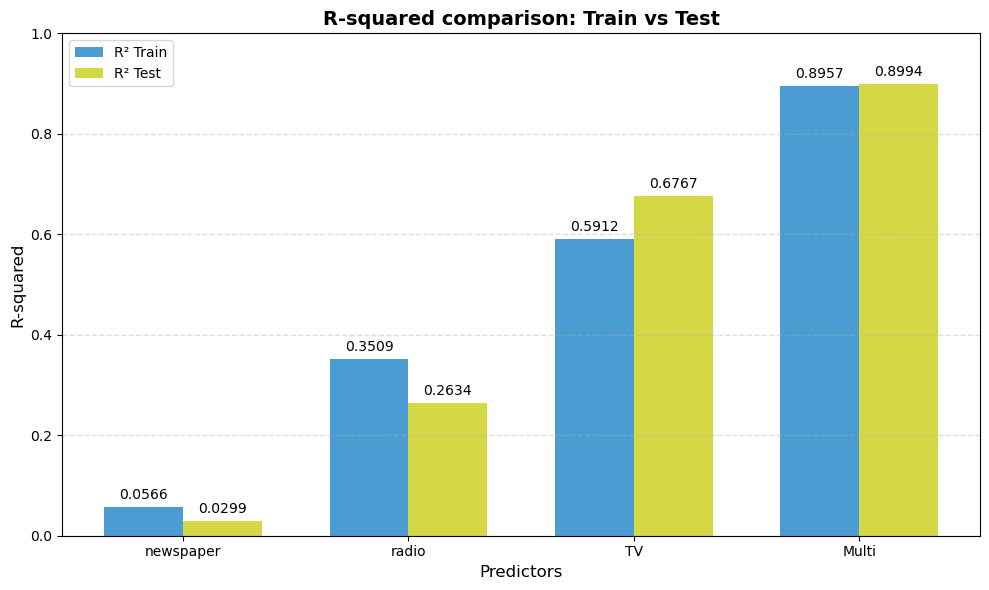

In [307]:
import matplotlib.pyplot as plt
import numpy as np

x_bars = np.array(df_models.iloc[:, 0])
y_r2_train = np.array(df_models.iloc[:, 1])
y_r2_test = np.array(df_models.iloc[:, 2])

x = np.arange(len(x_bars))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, y_r2_train, width, color='#4B9CD3', label='R² Train')
bars2 = plt.bar(x + width/2, y_r2_test, width, color="#D4D845", label='R² Test')

plt.xlabel('Predictors', fontsize=12)
plt.ylabel('R-squared', fontsize=12)
plt.title('R-squared comparison: Train vs Test', fontsize=14, weight='bold')
plt.xticks(x, x_bars)
plt.ylim(0, 1.0)
plt.legend()

for bar_group in [bars1, bars2]:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', linewidth=1, alpha=0.4)
plt.tight_layout()
plt.show()
